In [23]:
from collections import defaultdict
from importlib import reload
import kagglehub
import json
from PIL import Image
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
import segmentation
import preprocessing as pre
import matplotlib.path as matpat
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
import optuna

In [24]:
# Load images

def get_images(download_dataset_flag):
    if download_dataset_flag:
        dataset_path = kagglehub.dataset_download("humansintheloop/teeth-segmentation-on-dental-x-ray-images")
        sources = {k: Path(dataset_path) / f'Teeth Segmentation {k}' for k in ['JSON', 'PNG']}
    else:
        dataset_root = Path(r"")
        sources = {k: dataset_root / f'./Teeth Segmentation {k}' for k in ['JSON', 'PNG']}

    meta = {}
    for p in sources.values():
        meta.update(json.loads((p / 'meta.json').read_text()))

    images = [
        (Image.open(img_path), img_path)
        for p in sources.values()
        for img_path in (p / 'd2' / 'img').glob('*')
    ]

    images_np = [(np.array(image), str(p)) for (image, p) in images[:len(images)//2]]
    return images_np

In [25]:
DOWNLOAD_DATASET = True

images_np = get_images(DOWNLOAD_DATASET)

In [44]:
# Get general info about images size

shapes = []
for image, p in images_np:
    shapes.append(image.shape)

min_width = np.min(np.array(shapes)[:, 1])
max_width = np.max(np.array(shapes)[:, 1])
min_height = np.min(np.array(shapes)[:, 0])
max_height = np.max(np.array(shapes)[:, 0])
avg_width = np.median(np.array(shapes)[:, 1])
avg_height = np.median(np.array(shapes)[:, 0])

print(min_width, max_width, min_height, max_height, avg_width, avg_height)


1394 2045 1024 1024 2041.0 1024.0


In [45]:
# Method changes image size and calculates new polygon positions (but do not save them so we need to either run it every time of rewrite it to save new data

def normalize_image_size(image, image_metadata, output_height=1024, output_width=2045):
    image_height, image_width = image.shape

    scale_y = output_height / image_height
    scale_x = output_width / image_width

    resized_image = cv2.resize(image, (output_width, output_height))
    image_metadata['size'] = {
        'height': output_height,
        'width': output_width,
    }

    for segment_no in range(len(image_metadata['objects'])):
        for vertex_no in range(len(image_metadata['objects'][segment_no]['points']['exterior'])):
            x = image_metadata['objects'][segment_no]['points']['exterior'][vertex_no][0]
            y = image_metadata['objects'][segment_no]['points']['exterior'][vertex_no][1]
            image_metadata['objects'][segment_no]['points']['exterior'][vertex_no][0] = int(x*scale_x)
            image_metadata['objects'][segment_no]['points']['exterior'][vertex_no][1] = int(y*scale_y)

    return resized_image, image_metadata

<h3> Adjust images sobie podmienilem, bo mi sie scizki nie zgadzaly zamiencie to sobie z powrotem </h3>

In [46]:
import copy

# Method transforms image_number raw images and metadata to resized images and metadata
def adjust_images(images_with_paths, image_number=None):
    normalized_images = []
    images_with_metadata = []
    for image, image_path in images_with_paths[:image_number if image_number else len(images_with_paths)]:
        metadata_filename = image_path.split('/')[-1] + '.json'
        metadata_path = '/'.join(image_path.split('/')[:-2]) + '/ann/' + metadata_filename
        with open(metadata_path, 'r') as f:
            image_metadata = json.load(f)
        images_with_metadata.append((image, image_metadata, image_path))
        resized_image, resized_image_metadata = normalize_image_size(image, copy.deepcopy(image_metadata))
        normalized_images.append((resized_image, resized_image_metadata))

    return np.array(normalized_images, dtype=object), np.array(images_with_metadata, dtype=object)

In [47]:
def get_image_names(images_with_paths):
    return [p.split('\\')[-1] for _, p in images_with_paths]

In [48]:
resized_images_np, original_images_np = adjust_images(images_np)

In [49]:
debug=False

<h4> Szukanie cetroidow </h4>

In [32]:
reload(segmentation)
reload(pre)

class ToothDetector:
    PATCH_SIZE = (32, 64)
    HOG_PARAMS = dict(pixels_per_cell=(8, 8), cells_per_block=(2, 2), orientations=9)
    COLORS = {
        (True, True): ('lime', 'TP'),
        (True, False): ('orange', 'FN'),
        (False, True): ('purple', 'FP'),
        (False, False): ('blue', 'TN'),
    }

    def __init__(self, segment=segmentation.segment_teeth_watershed, preprocess=pre.preprocess_dental_xray, kernel_shape=(3, 30), svc_kw=None):
        self.segment = segment
        self.preprocess = preprocess
        self.kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_shape)
        self.pipe = make_pipeline(
            StandardScaler(),
            SVC(**(svc_kw or dict(kernel='rbf', C=3, class_weight={1: 1, 0: 1}, gamma='auto')))
        )

    # ── Image processing ──────────────────────────────────────────────

    def _roi(self, image):
        blurred = cv2.GaussianBlur(image, (7, 7), sigmaX=2, sigmaY=2)
        return cv2.erode(self.preprocess(blurred), self.kernel)

    def _segments(self, roi):
        """Yield (pixel_indices, centroid_xy, hog_vector) per valid segment."""
        _, _, markers = self.segment(roi)
        for seg in np.unique(markers):
            if seg <= 1:
                continue
            idx = np.argwhere(markers == seg)
            if np.ptp(idx, axis=0).min() < 16:
                continue
            (r0, c0), (r1, c1) = idx.min(0), idx.max(0)
            patch = cv2.resize(roi[r0:r1, c0:c1], self.PATCH_SIZE)
            centroid = idx.mean(0)[::-1]  # (x, y)
            yield idx, centroid, hog(patch, **self.HOG_PARAMS)

    @staticmethod
    def _match_teeth(centroid, tooth_paths):
        """Check if centroid falls inside any annotated tooth polygon."""
        return any(p.contains_points([centroid]) for p in tooth_paths)


    def _gather(self, images, rng):
        """ Gathering data from images """
        all_feats, all_labels, teeth_counts = [], [], []
        for i in rng:
            paths = [matpat.Path(p) for p in segmentation.get_teeth_positions(images[i, 1])]
            roi = self._roi(images[i, 0])

            for _, centroid, feat in self._segments(roi):
                all_feats.append(feat)
                all_labels.append(self._match_teeth(centroid, paths))

            teeth_counts.append(len(paths))

        return np.array(all_feats), np.array(all_labels), teeth_counts

    def train(self, images, train_rng, test_rng):
        """ Training SVC on given arguments """
        x_tr, y_tr, _ = self._gather(images, train_rng)
        x_te, y_te, self.test_teeth = self._gather(images, test_rng)

        self.pipe.fit(x_tr, y_tr)

        for x, y, title in [(x_tr, y_tr, 'Train'), (x_te, y_te, 'Test')]:
            ConfusionMatrixDisplay.from_estimator(self.pipe, x, y)
            plt.title(title)
            plt.show()

        preds = self.pipe.predict(x_te)
        tp = np.sum(y_te & preds.astype(bool))
        print(f'Avg % teeth detected: {tp / sum(self.test_teeth) * 100:.2f}%')

    def predict_teeth(self, image):
        """Return (N, 2) array of centroids for segments classified as teeth."""
        roi = self._roi(image)
        centroids, feats = zip(*[(c, h) for _, c, h in self._segments(roi)]) or ([], [])

        if not feats:
            return np.empty((0, 2))

        mask = self.pipe.predict(np.array(feats)).astype(bool)
        return np.array(centroids)[mask]

    def visualize(self, images, rng):
        # Wizualizacja klasyfikacji
        for i in rng:
            roi = self._roi(images[i, 0])
            paths = [matpat.Path(p) for p in segmentation.get_teeth_positions(images[i, 1])]
            segs = list(self._segments(roi))
            if not segs:
                continue

            idxs, cents, feats = zip(*segs)
            preds = self.pipe.predict(np.array(feats)).astype(bool)
            truths = [self._match_teeth(c, paths) for c in cents]

            plt.figure(figsize=(15, 7))
            plt.imshow(roi)

            seen = set()
            for idx, truth, pred in zip(idxs, truths, preds):
                color, label = self.COLORS[(truth, pred)]
                plt.scatter(idx[:, 1], idx[:, 0], s=0.5, c=color,
                            label=label if color not in seen else None)
                seen.add(color)

            tp = sum(t and p for t, p in zip(truths, preds))
            plt.title(f'{tp}/{len(paths)} teeth ({tp / len(paths) * 100:.0f}%)')
            plt.axis('off')
            plt.legend(markerscale=5)
            plt.show()


# Precompute segments once since image params are fixed
detector = ToothDetector(
    segment=lambda img: segmentation.segment_teeth_watershed(img, threshold=0.1)
)
cached_train = detector._gather(resized_images_np, range(50))
cached_test = detector._gather(resized_images_np, range(200, 240))

def objective(trial):
    x_tr, y_tr, _ = cached_train
    x_te, y_te, _ = cached_test

    C = trial.suggest_float('C', 0.1, 50, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 0.01, log=True)
    tooth_weight = trial.suggest_float('tooth_weight', 1.0, 5.0)

    pipe = make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', C=C, gamma=gamma, class_weight={1: tooth_weight, 0: 1})
    )
    pipe.fit(x_tr, y_tr)
    preds = pipe.predict(x_te)
    return f1_score(y_te, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=120, n_jobs=-1)

print(f'Best params: {study.best_params}')
print(f'Best F1: {study.best_value:.4f}')

# Predict tooth centroids on a new image - dobra no chce miec to z bani:
# centroids = detector.predict_teeth(some_image)

[I 2026-02-10 16:39:44,312] A new study created in memory with name: no-name-1dec76cb-4166-4f49-85f5-c2479f78af24
[I 2026-02-10 16:40:13,906] Trial 11 finished with value: 0.3406998158379374 and parameters: {'C': 0.2350353927806292, 'gamma': 0.0003863574005176276, 'tooth_weight': 1.356779758317972}. Best is trial 11 with value: 0.3406998158379374.
[I 2026-02-10 16:40:15,559] Trial 3 finished with value: 0.011737089201877934 and parameters: {'C': 0.4120573003409579, 'gamma': 0.00010030395337302533, 'tooth_weight': 1.2532725852443987}. Best is trial 11 with value: 0.3406998158379374.
[I 2026-02-10 16:40:16,270] Trial 6 finished with value: 0.5994500458295142 and parameters: {'C': 1.223849840360361, 'gamma': 0.0001479251986372574, 'tooth_weight': 2.718229955727572}. Best is trial 6 with value: 0.5994500458295142.
[I 2026-02-10 16:40:16,628] Trial 8 finished with value: 0.5988103106411103 and parameters: {'C': 0.49020073608972137, 'gamma': 0.0012669584969976773, 'tooth_weight': 1.741518239

Best params: {'C': 1.1587770682308718, 'gamma': 0.0009591653433402638, 'tooth_weight': 2.78630931932599}
Best F1: 0.6325


<h4> Wizualizacja </h4>

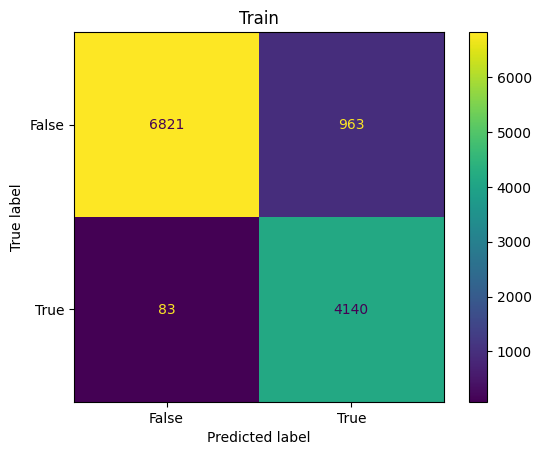

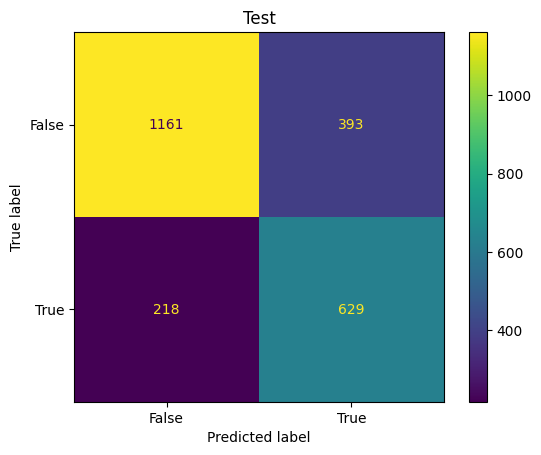

Avg % teeth detected: 59.23%


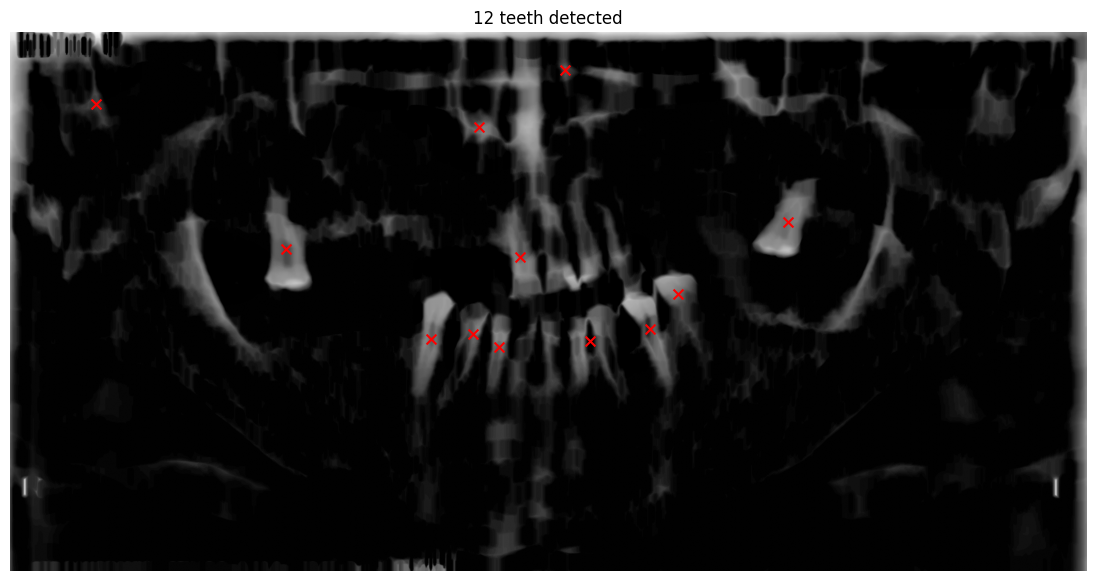

In [ ]:
best = study.best_params

detector = ToothDetector(
    segment=lambda img: segmentation.segment_teeth_watershed(img, threshold=0.1),
    svc_kw=dict(kernel='rbf', C=best['C'], gamma=best['gamma'],
                class_weight={1: best['tooth_weight'], 0: 1})
)

# ten drugi range ma bardzo duzy wplyw na dlugosc treningu
detector.train(resized_images_np, range(200), range(200, 240))

centroids = detector.predict_teeth(resized_images_np[300, 0])

image = detector._roi(resized_images_np[300, 0])
plt.figure(figsize=(15, 7))
plt.imshow(image, cmap='gray')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=300, marker='x')
plt.title(f'{len(centroids)} teeth detected')
plt.axis('off')
plt.show()

<h4> Przyklad segmentacji mean-shiftem z centroidami </h4>

In [51]:
reload(segmentation)
from segmentation import segment_with_mean_shift

for i in range(350, 355):
    preprocessed = resized_images_np[i, 0]
    centroids_array = detector.predict_teeth(preprocessed)

    image = detector._roi(resized_images_np[i, 0])
    centroids_dict = {i: tuple(c) for i, c in enumerate(centroids_array)}
    contours, _ = segment_with_mean_shift(image, centroids_dict, sp=12, sr=30, debug=False)
    


Ząb 4 obcięty odległością od centroidu: 21408 → 16000
Ząb 11 obcięty odległością od centroidu: 18890 → 16000
Ząb 7 obcięty odległością od centroidu: 16584 → 16000


In [10]:
def extract_jaw_directional_edges(image):
    # Method detects multiple edges on the image, thanks to high clipLimit on CLAHE and very small threshold params on Canny method, then arctan between sobel mask edges in both directions, and try to keep only horizontal edges, for us to see more clearly the jawbone shape
    clahe = cv2.createCLAHE(clipLimit=15.0, tileGridSize=(4,4))
    enhanced = clahe.apply(image)
    if debug:
        plt.imshow(enhanced, cmap='gray')
        plt.show()
    blurred = cv2.GaussianBlur(enhanced, (3,3), 0)
    edges = cv2.Canny(blurred, threshold1=0, threshold2=20)
    if debug:
        plt.imshow(edges, cmap='gray')
        plt.show()

    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=11)
    sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=11)
    edge_angle = np.arctan2(sobely, sobelx)

    h, w = image.shape
    center_x, center_y = w // 2, h // 2
    filtered_edges = np.zeros_like(edges)

    edge_coords = np.argwhere(edges > 0)

    for y, x in edge_coords:
        dx = x - center_x
        dy = y - center_y

        pixel_angle = np.arctan2(dy, dx)
        gradient_angle = edge_angle[y, x]
        angle_diff = abs(pixel_angle - gradient_angle)
        if angle_diff < np.pi / 2 or angle_diff > 3 * np.pi / 2:
            filtered_edges[y, x] = 255

    if debug:
        plt.imshow(filtered_edges, cmap='gray')
        plt.show()

    return filtered_edges

In [11]:
def find_upper_mandible_border(idx, image, original):
    # Method finds horizontal lines without edges in the middle of the "Canny+Sobel" edged images, and for every horizontal line, check its difference to neighbouring (10 px lower) lines, if the difference is high, we set the line as a probable jawbone upper edge, use the line with the lowest position as a final jawbone upper edge
    h, w = image.shape
    image = cv2.GaussianBlur(image, (5,5), 0)
    if debug:
        plt.imshow(image, cmap='gray')
        plt.show()

    margin = int(w * 0.25)
    roi = image[:, margin:-margin]
    if debug:
        plt.imshow(roi, cmap='gray')
        plt.show()

    proj = np.sum(roi, axis=1).astype(np.float32)
    proj = cv2.GaussianBlur(proj.reshape(-1,1), (1,51), 0).flatten()
    search_from = int(h*0.02)
    search_to   = int(h*0.35)

    v=10
    ys = []
    diffs = []
    for y in range(search_from+v, search_to):
        diff = proj[y-v:y].mean() - proj[y:y+v].mean()
        ys.append(y)
        diffs.append(diff)

    diffs = np.array(diffs)
    ys = np.array(ys)
    max_diff = np.max(diffs)
    max_y = ys[np.argmax(diffs)]

    y_to_check = ys[diffs > (2500 if max_diff * 0.4 > 2500 else max_diff*0.4)]
    if debug:
        print(f"{idx}: Detected upper border at row: {max_y}, {max_diff}")

    vis = cv2.cvtColor(original, cv2.COLOR_GRAY2BGR)
    cv2.line(vis, (0, max_y), (w, max_y), (0, 255, 0), 3)
    for y in y_to_check:
        cv2.line(vis, (0, y), (w, y), (255, 0, 0), 3)
    cv2.line(vis, (0, int(h*0.4)), (w, int(h*0.4)), (0, 0, 255), 3)

    return vis, y_to_check[-1]

In [12]:
top_crop_images = []
# Crop every image (10% from the bottom and some part from the top)
for idx in range(len(resized_images_np)):
    original_img, metadata = resized_images_np[idx]
    h, w = original_img.shape

    original_img = original_img[0:int(h*0.9), :]

    edge_img = extract_jaw_directional_edges(original_img)
    result_img, top_y_bound = find_upper_mandible_border(idx, edge_img, original_img)

    top_crop_image = original_img[top_y_bound:, :]

    top_crop_images.append((top_crop_image, (metadata, top_y_bound)))

In [13]:
def create_bone_mask(image):
    # Find the jawbone on the cropped image, adaptive thresholding, then erosion of the left and right 15% of the image, to separate jawbone from the noise and light on the image, then find contours on the image, and get all that are bigger than some threshold = 30000 of its area, then combine all the chosen edges, create convex hull around them, and its shape is the mask that contains jawbone
    binary = cv2.adaptiveThreshold(
        image,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=1501,
        C=10
    )
    if debug:
        plt.imshow(binary, cmap='gray')
        plt.show()

    w,h = binary.shape
    part = 0.15
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (23,23))
    binary[:, :int(w*part)] = cv2.morphologyEx(binary[:, :int(w*part)], cv2.MORPH_ERODE, kernel, iterations=6)
    binary[:, -int(w*part):] = cv2.morphologyEx(binary[:, -int(w*part):], cv2.MORPH_ERODE, kernel, iterations=6)

    if debug:
        plt.imshow(binary, cmap='gray')
        plt.show()

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return np.ones_like(image) * 255

    jaw_contours = sorted(contours, key=cv2.contourArea, reverse=True)
    jaw_mask_before = np.zeros_like(image)
    max_contour = 30_000
    i=0
    chosen_contours = []
    while cv2.contourArea(jaw_contours[i]) >= max_contour:
        cv2.drawContours(jaw_mask_before, [jaw_contours[i]], -1, 255, -1)
        chosen_contours.append(jaw_contours[i])
        i+=1
    if debug:
        print(np.unique(jaw_mask_before))
        plt.imshow(jaw_mask_before, cmap='gray')
        plt.show()

    h, w = jaw_mask_before.shape
    combined_points = np.vstack(chosen_contours)
    boundary = cv2.convexHull(combined_points)

    if debug:
        vis = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        for contour in chosen_contours:
            cv2.drawContours(vis, [contour], -1, (0, 255, 0), 2)
        cv2.drawContours(vis, [boundary], -1, (255, 255, 0), 3)
        plt.imshow(vis, cmap='gray')
        plt.show()

    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.drawContours(mask, [boundary], -1, 255, -1)

    if debug:
        plt.imshow(mask, cmap='gray')
        plt.show()

    return mask

def apply_bone_mask(image, mask):
    # Use mask on the xray image
    return cv2.bitwise_and(image, image, mask=mask)


In [14]:
def update_image_metadata(masked_image, resized_metadata):
    image_height, image_width = masked_image.shape
    metadata, top_y = resized_metadata
    metadata = copy.deepcopy(metadata)
    metadata['size'] = {
        'height': image_height,
        'width': image_width,
    }

    for segment_no in range(len(metadata['objects'])):
        for vertex_no in range(len(metadata['objects'][segment_no]['points']['exterior'])):
            y = metadata['objects'][segment_no]['points']['exterior'][vertex_no][1]
            y -= top_y
            if y < 0:
                y = 0
            if y > image_height-1:
                y = image_height-1
            metadata['objects'][segment_no]['points']['exterior'][vertex_no][1] = y

    return metadata

In [15]:
masked_images = []
for idx in range(len(resized_images_np)):
    original_img, metadata = top_crop_images[idx]
    h, w = original_img.shape

    denoised = cv2.bilateralFilter(original_img, 1, 50, 50)
    clahe = cv2.createCLAHE(clipLimit=20.0, tileGridSize=(8,8))
    denoised = clahe.apply(denoised)

    bone_mask = create_bone_mask(denoised)
    teeth_region = apply_bone_mask(original_img, bone_mask)
    # plt.imshow(teeth_region, cmap='gray')
    # plt.show()
    masked_metadata = update_image_metadata(teeth_region, metadata)
    masked_images.append(((bone_mask, teeth_region), masked_metadata))


In [16]:
#  Display ground truth contours on the cropped + jawbone masked images

def display_contours_on_masked_image(masked_images_data, image_idxs):
    for ((_, masked_image), metadata), image_idx in zip(masked_images_data, image_idxs):
        xs = []
        ys = []
        for segment_no in range(len(metadata['objects'])):
            arr = np.array(metadata['objects'][segment_no]['points']['exterior'])
            arr = np.concatenate((arr, np.array(metadata['objects'][segment_no]['points']['exterior'][0]).reshape(1,2)))
            xs.append(arr[:, 0])
            ys.append(arr[:, 1])

        plt.imshow(masked_image, cmap='gray')
        plt.title(f'Image {image_idx}')
        for x, y in zip(xs, ys):
            plt.plot(x, y)
        plt.axis('off')

        plt.show()

In [ ]:
idxs = sorted([str(i) for i in range(1,len(resized_images_np)+1)])
display_contours_on_masked_image(masked_images[:10], idxs[:10])

In [18]:
teeth_class_to_teeth_type_map = {}
for i in range(1,33):
    if i in [1,2,3,14,15,16,17,18,19,30,31,32]:
        teeth_class_to_teeth_type_map[i] = 0
    elif i in [4,5,12,13,20,21,28,29]:
        teeth_class_to_teeth_type_map[i] = 1
    elif i in [6,11,22,27]:
        teeth_class_to_teeth_type_map[i] = 2
    elif i in [7,8,9,10,23,24,25,26]:
        teeth_class_to_teeth_type_map[i] = 3

In [19]:
#  Method to separate xrays of children teeth and some corrupted data (multiple contours for teeth of the same class, we discard 64 photos here)

def discard_children_teeth_xrays(one_masked_image_data):
    (_, masked_image), metadata = one_masked_image_data
    xs = []
    ys = []
    teeth_classes = []
    teeth_types = []
    for segment_no in range(len(metadata['objects'])):
        arr = np.array(metadata['objects'][segment_no]['points']['exterior'])
        arr = np.concatenate((arr, np.array(metadata['objects'][segment_no]['points']['exterior'][0]).reshape(1,2)))
        teeth_classes.append(int(metadata['objects'][segment_no]['classTitle']))
        teeth_types.append(teeth_class_to_teeth_type_map[teeth_classes[-1]])
        xs.append(arr[:, 0])
        ys.append(arr[:, 1])

    if len(set(teeth_classes)) != len(teeth_classes) != 0:
        return False
    return True

In [20]:
masked_images_adults = []
idxs_adults = []
masked_images_children = []
idxs_children = []
for masked_image_data, idx in zip(masked_images, idxs):
    result = discard_children_teeth_xrays(masked_image_data)
    if result:
        masked_images_adults.append(masked_image_data)
        idxs_adults.append(idx)
    else:
        masked_images_children.append(masked_image_data)
        idxs_children.append(idx)

In [21]:
print(len(masked_images_adults), len(masked_images_children))

534 64


In [35]:
# Get shape features / descriptors from single contour

def get_contour_features(contour):
    features = {}
    features['area'] = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)

    x, y, w, h = cv2.boundingRect(contour)
    features['bbox_width'] = w
    features['bbox_height'] = h
    features['bbox_area'] = w * h
    features['aspect_ratio'] = h / w if w > 0 else 0

    hull = cv2.convexHull(contour)
    hull_perimeter = cv2.arcLength(hull, True)
    features['convexity'] = hull_perimeter / perimeter
    features['circularity'] = (4 * np.pi * features['area']) / (perimeter ** 2)

    if len(contour) >= 5:
        ellipse = cv2.fitEllipse(contour)
        center, axes, angle = ellipse
        major_axis = max(axes)
        minor_axis = min(axes)

        features['ellipse_minor_axis'] = minor_axis
        features['ellipse_eccentricity'] = np.sqrt(1 - (minor_axis/major_axis)**2) if major_axis > 0 else 0
    else:
        return None

    _, radius = cv2.minEnclosingCircle(contour)
    circle_area = np.pi * (radius ** 2)
    features['circle_occupancy'] = features['area'] / circle_area if circle_area > 0 else 0

    moments = cv2.moments(contour)
    hu_moments = cv2.HuMoments(moments).flatten()
    hu_moments_log = -np.sign(hu_moments) * np.log10(np.abs(hu_moments) + 1e-10)

    for i, hu in enumerate(hu_moments_log[:2]):
        features[f'hu_moment_{i+1}'] = hu

    mask = np.zeros(image.shape, dtype=np.uint8)
    cv2.drawContours(mask, [contour], -1, 255, -1)

    tooth_pixels = image[mask == 255]
    features['intensity_mean'] = np.mean(tooth_pixels)

    return features


In [231]:
from collections import defaultdict

#  Method to get teeth features from ground truth segments, later to be replaced with contours given by segmentation method

def get_teeth_features(one_masked_image_data):
    (_, masked_image), metadata = one_masked_image_data
    teeth_classes = []
    teeth_types = []
    teeth_features = defaultdict(lambda: list())
    for segment_no in range(len(metadata['objects'])):
        arr = np.array(metadata['objects'][segment_no]['points']['exterior'])
        arr = np.concatenate((arr, np.array(metadata['objects'][segment_no]['points']['exterior'][0]).reshape(1,2)))
        teeth_classes.append(int(metadata['objects'][segment_no]['classTitle']))
        teeth_contour = np.stack([arr[:, 0], arr[:, 1]], axis=1)
        teeth_contour = teeth_contour.reshape(-1, 1, 2)
        segment_features = get_contour_features(teeth_contour)
        if segment_features:
            for k, v in segment_features.items():
                teeth_features[k].append(v)
            teeth_types.append(teeth_class_to_teeth_type_map[teeth_classes[-1]])

    return teeth_features, teeth_types, teeth_classes

In [232]:
all_images_features = defaultdict(lambda: list())
all_images_teeth_types = list()
for masked_image_data, idx in zip(masked_images_adults, idxs_adults):
    one_image_features, one_image_teeth_types, _ = get_teeth_features(masked_image_data)
    for k,v in one_image_features.items():
        all_images_features[k].extend(v)
    all_images_teeth_types.extend(one_image_teeth_types)

for k,v in all_images_features.items():
    print(k, len(v))

area 13250
bbox_width 13250
bbox_height 13250
bbox_area 13250
aspect_ratio 13250
convexity 13250
circularity 13250
ellipse_minor_axis 13250
ellipse_eccentricity 13250
circle_occupancy 13250
hu_moment_1 13250
hu_moment_2 13250
intensity_mean 13250


In [44]:
import pandas as pd

df = pd.DataFrame(all_images_features)
print(df.head())
df_np = df.to_numpy()
print(df_np[0])

     area  bbox_width  bbox_height  bbox_area  aspect_ratio  convexity  \
0  8417.5          69          188      12972      2.724638   0.998945   
1  9445.5          71          195      13845      2.746479   0.998064   
2  5447.0          57          151       8607      2.649123   0.998831   
3  9796.5          80          200      16000      2.500000   0.998658   
4  6600.0          65          167      10855      2.569231   0.993366   

   circularity  ellipse_minor_axis  ellipse_eccentricity  circle_occupancy  \
0     0.515722          127.893707              0.998755          0.291687   
1     0.523186           77.523643              0.994653          0.296162   
2     0.535187           48.507046              0.966736          0.301358   
3     0.578341           66.361656              0.951085          0.302676   
4     0.505957           56.794594              0.957792          0.286052   

   hu_moment_1  hu_moment_2  intensity_mean  
0     0.475734     1.097488      115.354

In [46]:
import pickle

with open('teeth_type_svm.pkl','rb') as f:
    clf = pickle.load(f)
with open('scaler.pkl','rb') as f:
    scaler = pickle.load(f)

In [47]:
df_np = scaler.transform(df_np)
pred = clf.predict(df_np)

In [48]:
from sklearn.metrics import accuracy_score

print(accuracy_score(pred, all_images_teeth_types))

0.7969056603773584


In [82]:
for i in range(5):
    decision = clf.decision_function(df_np[i].reshape(1, -1))[0]
    print(clf.predict(df_np[i].reshape(1, -1)))
    print(decision)
    confidence = np.max(np.abs(decision)) / (np.sum(np.abs(decision)) + 1e-10)
    print(confidence)

[0]
[ 3.28221527  0.80202231 -0.27343367  2.11209315]
0.5073160424124669
[0]
[ 3.29402191  2.15098961 -0.28522636  0.76533424]
0.5071180565948618
[1]
[-0.29472867  3.26920449  2.24176372  1.14778195]
0.4701537999928727
[1]
[-0.28267484  3.28116322  2.04399736  1.01238579]
0.49562742919818253
[2]
[-0.29803473  2.24952689  3.27506232  1.14235831]
0.4702183293632024


<h1> New code starts from here </h1>

In [22]:
def get_teeth_positions(masked_images_data, masked_images_idxs):
    upper_jaw_teeth_data = {}
    lower_jaw_teeth_data = {}
    for (_, metadata), idx in zip(masked_images_data, masked_images_idxs):
        xs = []
        ys = []
        one_image_upper_jaw_data = {}
        one_image_lower_jaw_data = {}
        for segment_no in range(len(metadata['objects'])):
            arr = np.array(metadata['objects'][segment_no]['points']['exterior'])
            arr = np.concatenate((arr, np.array(metadata['objects'][segment_no]['points']['exterior'][0]).reshape(1,2)))
            class_title = int(metadata['objects'][segment_no]['classTitle'])
            xs.append(arr[:, 0])
            ys.append(arr[:, 1])
            tooth_contour = np.stack([arr[:, 0], arr[:, 1]], axis=1)
            tooth_contour = tooth_contour.reshape(-1, 1, 2)

            moments = cv2.moments(tooth_contour)
            if moments['m00'] != 0:
                cx = moments['m10'] / moments['m00']
                cy = moments['m01'] / moments['m00']
            else:
                x, y, w, h = cv2.boundingRect(tooth_contour)
                cx = x + w/2
                cy = y + h/2

            if class_title <= 16:
                one_image_upper_jaw_data[class_title] = np.array([cx, cy])
            else:
                one_image_lower_jaw_data[class_title] = np.array([cx, cy])

        upper_jaw_teeth_data[int(idx)] = one_image_upper_jaw_data
        lower_jaw_teeth_data[int(idx)] = one_image_lower_jaw_data

    return upper_jaw_teeth_data, lower_jaw_teeth_data

In [23]:
upper_jaw_data, lower_jaw_data = get_teeth_positions(masked_images_adults, idxs_adults)

In [24]:
def filter_jawbones(jaw_data, jaw_type, min_teeth=12, max_gap=0, min_teeth_per_side=5):
    filtered_jaw_data = {}

    for image_idx, one_jaw_data in jaw_data.items():
        n_teeth = len(one_jaw_data)
        if n_teeth < min_teeth:
            continue

        teeth_ids = list(one_jaw_data.keys())
        if jaw_type == 'upper':
            left_teeth = [tooth_id for tooth_id in teeth_ids if 1 <= tooth_id <= 8]
            right_teeth = [tooth_id for tooth_id in teeth_ids if 9 <= tooth_id <= 16]
        else:
            left_teeth = [tooth_id for tooth_id in teeth_ids if 17 <= tooth_id <= 24]
            right_teeth = [tooth_id for tooth_id in teeth_ids if 25 <= tooth_id <= 32]

        if len(left_teeth) < min_teeth_per_side or len(right_teeth) < min_teeth_per_side:
            continue

        sorted_teeth_ids = sorted(teeth_ids)
        max_consecutive_gap = 0

        for i in range(len(sorted_teeth_ids) - 1):
            gap = sorted_teeth_ids[i+1] - sorted_teeth_ids[i] - 1
            max_consecutive_gap = max(max_consecutive_gap, gap)

        if max_consecutive_gap > max_gap:
            continue

        filtered_jaw_data[image_idx] = one_jaw_data

    print(f"Filtered: {len(jaw_data)} → {len(filtered_jaw_data)} jaws")
    print(f"Removed {len(jaw_data) - len(filtered_jaw_data)} jaws with poor coverage")

    return filtered_jaw_data

In [25]:
filtered_upper_jaw_data = filter_jawbones(upper_jaw_data, 'upper')
filtered_lower_jaw_data = filter_jawbones(lower_jaw_data, 'lower')

Filtered: 534 → 209 jaws
Removed 325 jaws with poor coverage
Filtered: 534 → 206 jaws
Removed 328 jaws with poor coverage


In [ ]:
i = 0
displayed = 0
while displayed < 10:
    disp = False
    jaw = filtered_upper_jaw_data.get(list(upper_jaw_data)[i], None)
    if jaw:
        disp = True
        positions = np.array([t for t in jaw.values()])
        plt.scatter(positions[:, 0], positions[:, 1], color='red')

    jaw = filtered_lower_jaw_data.get(list(lower_jaw_data)[i], None)
    if jaw:
        disp = True
        positions = np.array([t for t in jaw.values()])
        plt.scatter(positions[:, 0], positions[:, 1], color='blue')
    if disp:
        plt.imshow(masked_images_adults[i][0][1], cmap='gray')
        displayed += 1
        plt.title(f'Raw Tooth Positions (Before Normalization) {list(upper_jaw_data)[i]}')
        plt.show()
    i+=1

In [27]:
def normalize_jaw_configuration(one_image_teeth_data, reference_shape=None):
    positions = []
    teeth_ids = []
    for class_title, centroid in one_image_teeth_data.items():
        positions.append(centroid)
        teeth_ids.append(class_title)

    positions = np.array(positions)
    centroid = np.mean(positions, axis=0)
    centered_positions = positions - centroid

    scale = np.sqrt(np.sum(centered_positions ** 2))
    if scale > 0:
        normalized_positions = centered_positions / scale
    else:
        normalized_positions = centered_positions

    if reference_shape is not None:
        reference_teeth_ids = list(reference_shape.keys())
        common_idxs = [tooth_id for tooth_id in teeth_ids if tooth_id in reference_teeth_ids]

        if len(common_idxs) >= 3:
            source_points = np.array([normalized_positions[teeth_ids.index(tooth_id)] for tooth_id in common_idxs])
            target_points = np.array([reference_shape[tooth_id] for tooth_id in common_idxs])
            H = source_points.T @ target_points
            U, S, Vt = np.linalg.svd(H)
            R = Vt.T @ U.T

            if np.linalg.det(R) < 0:
                Vt[-1, :] *= -1
                R = Vt.T @ U.T

            normalized_positions = normalized_positions @ R

    normalized_jaw = {}
    for i, (class_title, centroid) in enumerate(one_image_teeth_data.items()):
        normalized_jaw[class_title] =  normalized_positions[i]
    return normalized_jaw

In [28]:
import math

def procrustes_alignment(jaw_teeth_data, max_iterations=10):
    reference_shape = normalize_jaw_configuration(jaw_teeth_data[list(jaw_teeth_data)[0]], reference_shape=None)
    aligned_jaws = []
    previous_diff = math.inf

    for iteration in range(max_iterations):
        aligned_jaws = []

        for one_jaw_data in jaw_teeth_data.values():
            normalized_jaw = normalize_jaw_configuration(one_jaw_data, reference_shape=reference_shape)
            aligned_jaws.append(normalized_jaw)

        all_tooth_idxs = set()
        for normalized_jaw in aligned_jaws:
            all_tooth_idxs.update(normalized_jaw.keys())

        new_reference_shape = {}
        for tooth_id in all_tooth_idxs:
            positions = []
            for normalized_jaw in aligned_jaws:
                if tooth_id in normalized_jaw:
                    positions.append(normalized_jaw[tooth_id])

            if len(positions) > 0:
                new_reference_shape[tooth_id] = np.mean(positions, axis=0)

        # Check convergence (compare to previous reference)
        common_idxs = set(reference_shape.keys()) & set(new_reference_shape.keys())
        if len(common_idxs) > 0:
            diff = np.mean([np.linalg.norm(reference_shape[tooth_id] - new_reference_shape[tooth_id]) for tooth_id in common_idxs])
            print(f"Iteration {iteration+1}: mean shift = {diff:.6f}")

            if diff < 1e-4:
                print(f"Converged after {iteration+1} iterations")
                break
            if math.isclose(previous_diff, diff, rel_tol=1e-8):
                print(f"Diff does not change after {iteration+1} iterations")
                break

            previous_diff = diff
        reference_shape = new_reference_shape

    return aligned_jaws, reference_shape


In [29]:
aligned_upper_jaws, upper_jaw_refenced_shape = procrustes_alignment(filtered_upper_jaw_data, max_iterations=1000)

Iteration 1: mean shift = 0.013883
Iteration 2: mean shift = 0.001135
Iteration 3: mean shift = 0.001129
Iteration 4: mean shift = 0.001128
Iteration 5: mean shift = 0.001128
Iteration 6: mean shift = 0.001128
Iteration 7: mean shift = 0.001128
Iteration 8: mean shift = 0.001128
Diff does not change after 8 iterations


In [30]:
aligned_lower_jaws, lower_jaw_refenced_shape = procrustes_alignment(filtered_lower_jaw_data, max_iterations=1000)

Iteration 1: mean shift = 0.017056
Iteration 2: mean shift = 0.003165
Iteration 3: mean shift = 0.003173
Iteration 4: mean shift = 0.003173
Iteration 5: mean shift = 0.003173
Iteration 6: mean shift = 0.003173
Iteration 7: mean shift = 0.003173
Iteration 8: mean shift = 0.003173
Iteration 9: mean shift = 0.003173
Diff does not change after 9 iterations


In [203]:
def build_statistical_template(aligned_jaws):
    tooth_positions = defaultdict(lambda: list())

    for jaw in aligned_jaws:
        for tooth_id, tooth_position in jaw.items():
            tooth_positions[tooth_id].append(tooth_position)
    template = {}

    for tooth_id, positions in tooth_positions.items():
        positions = np.array(positions)
        plt.scatter(positions[:, 0], positions[:, 1], label=tooth_id)

        template[tooth_id] = {
            'tooth_id': tooth_id,
            'n_samples': len(positions),
            'mean': list(np.mean(positions, axis=0)),
            'std': list(np.std(positions, axis=0)),
        }

    print(f"\nJAW TEMPLATE:")
    print(f"Total teeth in template: {len(template)}")

    plt.legend()
    plt.gca().invert_yaxis()
    plt.show()

    for tooth_id in sorted(template.keys()):
        t = template[tooth_id]
        print(f"Tooth {tooth_id}: n={t['n_samples']:3d}, "
              f"mean=({t['mean'][0]:7.4f}, {t['mean'][1]:7.4f}), "
              f"std=({t['std'][0]:.4f}, {t['std'][1]:.4f})")

    return template



JAW TEMPLATE:
Total teeth in template: 16


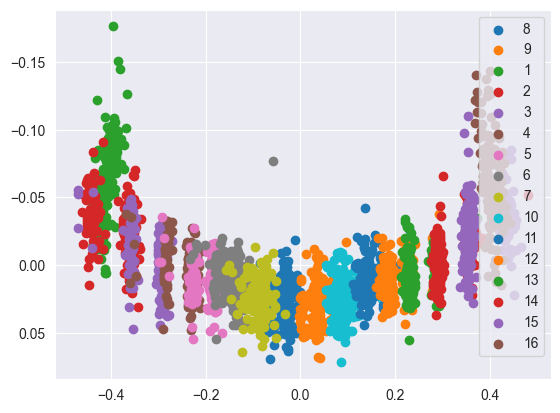

Tooth 1: n=151, mean=(-0.4105, -0.0622), std=(0.0155, 0.0306)
Tooth 2: n=204, mean=(-0.3810, -0.0264), std=(0.0363, 0.0195)
Tooth 3: n=209, mean=(-0.3129, -0.0062), std=(0.0368, 0.0174)
Tooth 4: n=209, mean=(-0.2467,  0.0034), std=(0.0293, 0.0151)
Tooth 5: n=209, mean=(-0.1966,  0.0113), std=(0.0252, 0.0134)
Tooth 6: n=209, mean=(-0.1455,  0.0094), std=(0.0222, 0.0139)
Tooth 7: n=209, mean=(-0.0884,  0.0233), std=(0.0180, 0.0128)
Tooth 8: n=209, mean=(-0.0329,  0.0273), std=(0.0160, 0.0142)
Tooth 9: n=209, mean=( 0.0339,  0.0273), std=(0.0149, 0.0140)
Tooth 10: n=209, mean=( 0.0896,  0.0244), std=(0.0164, 0.0130)
Tooth 11: n=209, mean=( 0.1462,  0.0108), std=(0.0185, 0.0122)
Tooth 12: n=209, mean=( 0.1953,  0.0113), std=(0.0216, 0.0125)
Tooth 13: n=209, mean=( 0.2444,  0.0048), std=(0.0269, 0.0135)
Tooth 14: n=209, mean=( 0.3078, -0.0061), std=(0.0333, 0.0163)
Tooth 15: n=206, mean=( 0.3741, -0.0260), std=(0.0356, 0.0215)
Tooth 16: n=158, mean=( 0.4040, -0.0594), std=(0.0145, 0.0310)



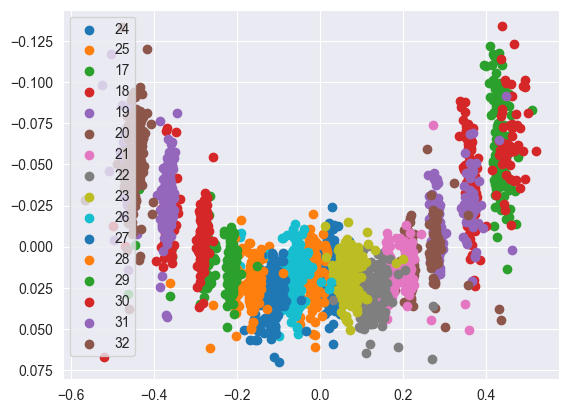

Tooth 17: n=149, mean=( 0.4332, -0.0614), std=(0.0144, 0.0263)
Tooth 18: n=201, mean=( 0.3861, -0.0434), std=(0.0442, 0.0258)
Tooth 19: n=204, mean=( 0.3039, -0.0143), std=(0.0402, 0.0171)
Tooth 20: n=206, mean=( 0.2340,  0.0071), std=(0.0366, 0.0142)
Tooth 21: n=206, mean=( 0.1765,  0.0166), std=(0.0298, 0.0120)
Tooth 22: n=206, mean=( 0.1231,  0.0296), std=(0.0252, 0.0114)
Tooth 23: n=206, mean=( 0.0674,  0.0177), std=(0.0218, 0.0113)
Tooth 24: n=206, mean=( 0.0237,  0.0166), std=(0.0211, 0.0127)
Tooth 25: n=206, mean=(-0.0188,  0.0166), std=(0.0220, 0.0128)
Tooth 26: n=206, mean=(-0.0633,  0.0182), std=(0.0241, 0.0129)
Tooth 27: n=206, mean=(-0.1203,  0.0307), std=(0.0283, 0.0123)
Tooth 28: n=206, mean=(-0.1754,  0.0204), std=(0.0338, 0.0116)
Tooth 29: n=206, mean=(-0.2341,  0.0107), std=(0.0413, 0.0118)
Tooth 30: n=203, mean=(-0.3061, -0.0085), std=(0.0437, 0.0162)
Tooth 31: n=199, mean=(-0.3915, -0.0364), std=(0.0445, 0.0220)
Tooth 32: n=150, mean=(-0.4446, -0.0547), std=(0.0169, 

In [216]:
upper_template = build_statistical_template(aligned_upper_jaws)
lower_template = build_statistical_template(aligned_lower_jaws)

In [217]:
def visualize_template(upper_jaw_template, lower_jaw_template):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    template_keys = list(upper_jaw_template.keys()) + list(lower_jaw_template.keys())
    tooth_idxs = sorted(template_keys)
    template = copy.copy(upper_jaw_template)
    template.update(lower_jaw_template)
    means = np.array([template[tooth_id]['mean'] for tooth_id in tooth_idxs])
    stds = np.array([template[tooth_id]['std'] for tooth_id in tooth_idxs])
    n_samples = [template[tooth_id]['n_samples'] for tooth_id in tooth_idxs]

    ax1.scatter(means[:, 0][:16], means[:, 1][:16], c='red', s=100, zorder=3, label='Mean position upper')
    ax2.scatter(means[:, 0][16:], means[:, 1][16:], c='blue', s=100, zorder=3, label='Mean position lower')

    for tid, mean, std in zip(tooth_idxs[:16], means, stds):
        ellipse = plt.Circle(mean, radius=2*np.mean(std), color='red', alpha=0.2)
        ax1.add_patch(ellipse)
        ax1.text(mean[0], mean[1], f'#{tid}', ha='center', va='center', fontsize=8, fontweight='bold')

    for tid, mean, std in zip(tooth_idxs[16:], means[16: ], stds[16: ]):
        ellipse = plt.Circle(mean, radius=2*np.mean(std), color='blue', alpha=0.2)
        ax2.add_patch(ellipse)
        ax2.text(mean[0], mean[1], f'#{tid}', ha='center', va='center', fontsize=8, fontweight='bold')

    ax1.set_xlabel('Normalized X')
    ax1.set_ylabel('Normalized Y')
    ax1.set_title(f'Upper Jaw Template - Mean Positions')
    ax1.grid(True, alpha=0.3)
    ax1.axis('equal')
    ax1.legend()

    ax2.set_xlabel('Normalized X')
    ax2.set_ylabel('Normalized Y')
    ax2.set_title(f'Lower Jaw Template - Mean Positions')
    ax2.grid(True, alpha=0.3)
    ax2.axis('equal')
    ax2.legend()

    ax1.invert_yaxis()
    ax2.invert_yaxis()

    sc = ax3.scatter(means[:16, 0], means[:16, 1], c=[np.mean(std) for std in stds[:16]], s=[n*5 for n in n_samples[:16]], cmap='coolwarm', zorder=3)

    for tid, mean in zip(tooth_idxs[:16], means):
        ax3.text(mean[0], mean[1], str(tid), ha='center', va='center', fontsize=8, fontweight='bold')

    ax3.set_xlabel('Normalized X')
    ax3.set_ylabel('Normalized Y')
    ax3.set_title(f'Upper Jaw Template - Position Uncertainty')
    ax3.axis('equal')
    ax3.grid(True, alpha=0.3)

    cbar = plt.colorbar(sc, ax=ax3)
    cbar.set_label('Mean Standard Deviation')

    sc = ax4.scatter(means[16:, 0], means[16:, 1], c=[np.mean(std) for std in stds[16:]], s=[n*5 for n in n_samples[16:]], cmap='coolwarm', zorder=3)

    for tid, mean in zip(tooth_idxs[16:], means[16:]):
        ax4.text(mean[0], mean[1], str(tid), ha='center', va='center', fontsize=8, fontweight='bold')

    ax4.set_xlabel('Normalized X')
    ax4.set_ylabel('Normalized Y')
    ax4.set_title(f'Lower Jaw Template - Position Uncertainty')
    ax4.axis('equal')
    ax4.grid(True, alpha=0.3)

    ax3.invert_yaxis()
    ax4.invert_yaxis()

    cbar = plt.colorbar(sc, ax=ax4)
    cbar.set_label('Mean Standard Deviation')

    plt.tight_layout()
    plt.savefig('template_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
visualize_template(upper_template, lower_template)


In [207]:
print(upper_template[1])

{'tooth_id': 1, 'n_samples': 151, 'mean': [np.float64(-0.41050616692648334), np.float64(-0.06221943800173168)], 'std': [np.float64(0.015542583988734072), np.float64(0.030623167817878705)]}


In [220]:
with open('upper_jaw_template.json', 'w') as f:
    json.dump(upper_template, f, indent=4)

In [221]:
with open('lower_jaw_template.json', 'w') as f:
    json.dump(lower_template, f, indent=4)

Parabola before filtering:
- upper: Parabola: y = -0.3566*x^2 + 0.0043*x + 0.0258
- lower: Parabola: y = -0.4163*x^2 + -0.0012*x + 0.0287

Parabola after filtering:
- upper: Parabola: y = -0.4077*x^2 + 0.0032*x + 0.0266
- lower: Parabola: y = -0.4310*x^2 + 0.0039*x + 0.0284

In [ ]:
def get_teeth_positions(masked_images_data, masked_images_idxs):
    upper_jaw_teeth_data = {}
    lower_jaw_teeth_data = {}
    for (_, metadata), idx in zip(masked_images_data, masked_images_idxs):
        xs = []
        ys = []
        one_image_upper_jaw_data = {}
        one_image_lower_jaw_data = {}
        for segment_no in range(len(metadata['objects'])):
            arr = np.array(metadata['objects'][segment_no]['points']['exterior'])
            arr = np.concatenate((arr, np.array(metadata['objects'][segment_no]['points']['exterior'][0]).reshape(1,2)))
            class_title = int(metadata['objects'][segment_no]['classTitle'])
            xs.append(arr[:, 0])
            ys.append(arr[:, 1])
            tooth_contour = np.stack([arr[:, 0], arr[:, 1]], axis=1)
            tooth_contour = tooth_contour.reshape(-1, 1, 2)

            moments = cv2.moments(tooth_contour)
            if moments['m00'] != 0:
                cx = moments['m10'] / moments['m00']
                cy = moments['m01'] / moments['m00']
            else:
                x, y, w, h = cv2.boundingRect(tooth_contour)
                cx = x + w/2
                cy = y + h/2

            if class_title <= 16:
                one_image_upper_jaw_data[class_title] = np.array([cx, cy])
            else:
                one_image_lower_jaw_data[class_title] = np.array([cx, cy])

        upper_jaw_teeth_data[int(idx)] = one_image_upper_jaw_data
        lower_jaw_teeth_data[int(idx)] = one_image_lower_jaw_data

    return upper_jaw_teeth_data, lower_jaw_teeth_data

In [168]:
def separate_detected_jaws(masked_image, masked_image_metadata, idx, disp=False):
    global incorrect_count
    xs = []
    ys = []
    tops = []
    centroids = []
    bottoms = []
    contours = []
    classes = []
    for segment_no in range(len(masked_image_metadata['objects'])):
        arr = np.array(masked_image_metadata['objects'][segment_no]['points']['exterior'])
        arr = np.concatenate((arr, np.array(masked_image_metadata['objects'][segment_no]['points']['exterior'][0]).reshape(1,2)))
        classes.append(int(masked_image_metadata['objects'][segment_no]['classTitle']))
        xs.append(arr[:, 0])
        ys.append(arr[:, 1])
        tooth_contour = np.stack([arr[:, 0], arr[:, 1]], axis=1)
        tooth_contour = tooth_contour.reshape(-1, 1, 2)

        # moments = cv2.moments(tooth_contour)
        # if moments['m00'] != 0:
        #     cx = moments['m10'] / moments['m00']
        #     cy = moments['m01'] / moments['m00']
        # else:
        x, y, w, h = cv2.boundingRect(tooth_contour)
        # cx = x + w/2
        cy = y + h/2

        tops.append(y)
        centroids.append(cy)
        bottoms.append(y+h)
        contours.append(tooth_contour)

    classes = np.array(classes)
    expected_upper = np.sum(classes <= 16)
    expected_lower = len(classes) - expected_upper
    tops = np.array(tops)
    centroids = np.array(centroids)
    bottoms = np.array(bottoms)
    h, w = masked_image.shape

    # Method 1: Simple median split
    medium_y1 = np.min(tops) + h*0.33
    mask = centroids > medium_y1
    labels1 = np.zeros_like(centroids, dtype=int)
    meeting_indices = np.where(mask)[0]
    if len(meeting_indices) > 16:
        top_n_idx_within_meeting = np.argsort(centroids[meeting_indices])[-16:]
        final_indices = meeting_indices[top_n_idx_within_meeting]
        labels1[final_indices] = 1
    elif len(centroids) - len(meeting_indices) > 16:
        top_n_idx_within_meeting = np.argsort(centroids[meeting_indices])[:16]
        final_indices = meeting_indices[top_n_idx_within_meeting]
        labels1[final_indices] = 0
    else:
        labels1[mask] = 1

        # Method 1: Simple median split
    medium_y2 = np.min(tops) + h*0.225
    mask = tops > medium_y2
    labels2 = np.zeros_like(tops, dtype=int)
    meeting_indices = np.where(mask)[0]
    if len(meeting_indices) > 16:
        top_n_idx_within_meeting = np.argsort(centroids[meeting_indices])[-16:]
        final_indices = meeting_indices[top_n_idx_within_meeting]
        labels2[final_indices] = 1
    elif len(centroids) - len(meeting_indices) > 16:
        top_n_idx_within_meeting = np.argsort(centroids[meeting_indices])[:16]
        final_indices = meeting_indices[top_n_idx_within_meeting]
        labels2[final_indices] = 0
    else:
        labels2[mask] = 1

    # # labels1 = (centroids > medium_y1).astype(int)
    # medium_y2 = np.min(tops) + h*0.225
    # labels2 = (tops > medium_y2).astype(int)
    # upper_label = 0
    # median_y = np.median(positions)
    #
    # # Method 2: K-means clustering (more robust)
    # from sklearn.cluster import KMeans
    #
    # if len(positions) >= 4:
    #     kmeans = KMeans(n_clusters=2, random_state=42)
    #     labels = kmeans.fit_predict(positions.reshape(-1, 1))
    #
    #     cluster_means = [positions[labels == 0].mean(),
    #                     positions[labels == 1].mean()]
    #     upper_label = 0 if cluster_means[0] < cluster_means[1] else 1
    # else:
    #     labels = (positions > median_y).astype(int)
    #     upper_label = 0

    upper_teeth = []
    unk_teeth = []
    lower_teeth = []

    labels = []

    for i, tooth_contour in enumerate(contours):
        if labels1[i] == labels2[i] == 0:
            upper_teeth.append(tooth_contour)
            labels.append(0)
        elif labels1[i] == labels2[i]:
            lower_teeth.append(tooth_contour)
            labels.append(1)
        else:
            upper_teeth.append(tooth_contour)
            labels.append(0)
    labels = np.array(labels).astype(bool)
    if len(lower_teeth) == 0:
        if np.mean(centroids) > 0.5*h:
            lower_teeth = upper_teeth.copy()
            upper_teeth = []
            labels = ~labels

    if len(upper_teeth) != expected_upper:
        if disp:
            print(f"\nJAW SEPARATION:")
            print(f"  Upper jaw: {len(upper_teeth)} teeth, expected {expected_upper}")
            print(f"  Lower jaw: {len(lower_teeth)} teeth, expected {expected_lower}")
            print(f"  Unknown teeth: {len(unk_teeth)}")

            vis = cv2.cvtColor(masked_image, cv2.COLOR_GRAY2BGR)

            for tooth in upper_teeth:
                cv2.drawContours(vis, [tooth], -1, (0, 255, 0), 2)

            for tooth in lower_teeth:
                cv2.drawContours(vis, [tooth], -1, (0, 0, 255), 2)

            for tooth in unk_teeth:
                cv2.drawContours(vis, [tooth], -1, (255, 0, 0), 2)

            # Draw separation line
            # split_y = medium_y
            # if len(positions) >= 4:
            #     split_y = (cluster_means[0] + cluster_means[1]) / 2
            # else:
            #     split_y = median_y

            # cv2.line(vis, (0, int(split_y)), (w, int(split_y)), (255, 255, 0), 2)

            plt.title(f'Image {idx}')
            plt.imshow(vis, cmap='gray')
            plt.axis('off')
            plt.show()
        incorrect_count += 1

    return upper_teeth, lower_teeth, labels

In [159]:
incorrect_count = 0
for masked_image_data, idx in zip(masked_images_adults, idxs_adults):
    one_image_features, one_image_teeth_types, _ = get_teeth_features(masked_image_data)
    df = pd.DataFrame(one_image_features)
    df_np = df.to_numpy()
    if len(df_np) == 0:
        continue
    df_np = scaler.transform(df_np)
    pred = clf.predict(df_np)
    # print(one_image_teeth_types, pred)
    (_, masked_image), metadata = masked_image_data
    upper_detected, lower_detected, _ = separate_detected_jaws(masked_image, metadata, idx)
print(incorrect_count, len(idxs_adults))

57 534


57/534

In [222]:
def normalize_jaw_configuration_no_rotation(one_jaw_data):
    positions = []
    teeth_ids = []

    for temp_id, centroid in one_jaw_data.items():
        positions.append(centroid)
        teeth_ids.append(temp_id)

    positions = np.array(positions)
    centroid = np.mean(positions, axis=0)
    centered_positions = positions - centroid

    scale = np.sqrt(np.sum(centered_positions ** 2))
    if scale > 0:
        normalized_positions = centered_positions / scale
    else:
        normalized_positions = centered_positions

    normalized_jaw = {}
    for i, class_title in enumerate(teeth_ids):
        normalized_jaw[class_title] = normalized_positions[i]

    return normalized_jaw, centroid, scale

In [289]:
def debug_normalization(detected_teeth, template, jaw_type='upper'):
    """
    Check if normalization is working correctly
    """
    import matplotlib.pyplot as plt

    # Get detected positions (normalized)
    print(detected_teeth)
    detected_pos = np.array(list(detected_teeth.values()))
    print(detected_pos)

    # Get template positions
    template_ids = sorted(template.keys())
    template_pos = np.array([template[tid]['mean'] for tid in template_ids])

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Overlay
    print(template_pos.shape)
    print(detected_pos.shape)
    ax = axes[0]
    ax.scatter(template_pos[:, 0], template_pos[:, 1],
              c='red', s=200, alpha=0.5, marker='s', label='Template')
    ax.scatter(detected_pos[:, 0], detected_pos[:, 1],
              c='blue', s=100, alpha=0.7, marker='o', label='Detected')

    # Draw lines between closest pairs
    for i, det in enumerate(detected_pos):
        # Find closest template position
        distances = [np.linalg.norm(det - temp) for temp in template_pos]
        closest_idx = np.argmin(distances)
        closest_dist = distances[closest_idx]

        # Draw line
        ax.plot([det[0], template_pos[closest_idx, 0]],
               [det[1], template_pos[closest_idx, 1]],
               'gray', alpha=0.3, linestyle='--')

        ax.text(det[0], det[1], f"{closest_dist:.2f}",
               fontsize=8, ha='center', va='bottom')

    ax.set_title(f'{jaw_type.upper()}: Template vs Detected')
    ax.legend()
    ax.axis('equal')
    ax.grid(True, alpha=0.3)

    # Plot 2: Distance distribution
    ax = axes[1]

    all_distances = []
    for det in detected_pos:
        distances = [np.linalg.norm(det - temp) for temp in template_pos]
        min_dist = np.min(distances)
        all_distances.append(min_dist)

    ax.hist(all_distances, bins=20, edgecolor='black')
    ax.axvline(0.15, color='red', linestyle='--', label='Threshold (0.15)')
    ax.set_xlabel('Distance to Closest Template Position')
    ax.set_ylabel('Count')
    ax.set_title('Distance Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{jaw_type}_normalization_debug.png', dpi=150)
    plt.gca().invert_yaxis()
    plt.show()

    # Print statistics
    print(f"\n{jaw_type.upper()} JAW NORMALIZATION DEBUG:")
    print(f"  Detected teeth: {len(detected_pos)}")
    print(f"  Template positions: {len(template_pos)}")
    print(f"  Distance statistics:")
    print(f"    Min: {np.min(all_distances):.3f}")
    print(f"    Max: {np.max(all_distances):.3f}")
    print(f"    Mean: {np.mean(all_distances):.3f}")
    print(f"    Median: {np.median(all_distances):.3f}")
    print(f"    Within threshold (0.15): {np.sum(np.array(all_distances) < 0.15)}/{len(all_distances)}")

    return all_distances


In [300]:
def match_and_align_iteratively(detected_teeth, template, teeth_types, max_iterations=1, debug=True):
    if len(detected_teeth) < 2:
        return detected_teeth, [], []

    current_teeth = detected_teeth.copy()
    one_jaw_data = {}
    for i, tooth_contour in enumerate(current_teeth):
        moments = cv2.moments(tooth_contour)
        cx = moments['m10'] / moments['m00']
        cy = moments['m01'] / moments['m00']
        one_jaw_data[i] = np.array([cx, cy])

    normalized_jaw, centroid, scale = normalize_jaw_configuration_no_rotation(one_jaw_data)
    if debug:
        distances = debug_normalization(normalized_jaw, template)

    teeth_normalized_positions = {}
    for i, tooth_contour in enumerate(one_jaw_data):
        teeth_normalized_positions[i] = normalized_jaw[i]

    reference_shape = {tid: template[tid]['mean'] for tid in template.keys()}
    template_ids = sorted(template.keys())
    template_positions = np.array([template[tid]['mean'] for tid in template_ids])
    template_types = [teeth_class_to_teeth_type_map[tid] for tid in template_ids]
    detected_teeth_ids = {}
    for iteration in range(max_iterations):
        detected_positions = np.array([tooth_norm_pos for tooth_norm_pos in teeth_normalized_positions.values()])
        # STEP A: Match to template (same as Stage 5)
        from scipy.optimize import linear_sum_assignment

        n_detected = len(one_jaw_data)
        n_template = len(template_ids)
        cost_matrix = np.zeros((n_detected, n_template))

        for i in range(n_detected):
            for j in range(n_template):
                dist = np.linalg.norm(detected_positions[i] - template_positions[j])
                type_penalty = 0.5 if teeth_types[i] != template_types[j] else 0.0
                # cost_matrix[i, j] = dist + type_penalty
                cost_matrix[i, j] = dist

        row_ind, col_ind = linear_sum_assignment(cost_matrix)

        # Filter by distance threshold
        max_distance = 0.5
        assignments = []

        for i, j in zip(row_ind, col_ind):
            dist = np.linalg.norm(detected_positions[i] - template_positions[j])
            if dist < max_distance:
                tooth_id = template_ids[j]
                assignments.append((i, tooth_id))

        # if len(assignments) < 3:
        #     # Not enough matches, stop iteration
        #     break

        # STEP B: Re-normalize using matched tooth IDs
        # Now we can use YOUR normalize_jaw_configuration with proper IDs!

        matched_data = {}
        for det_idx, tooth_id in assignments:
            matched_data[tooth_id] = one_jaw_data[det_idx]

        # Call YOUR function with REAL tooth IDs
        normalized_with_rotation = normalize_jaw_configuration(
            matched_data,
            reference_shape=reference_shape
        )

        # Update positions
        for det_idx, tooth_id in assignments:
            teeth_normalized_positions[det_idx] = normalized_with_rotation[tooth_id]
            detected_teeth_ids[det_idx] = tooth_id
        if debug:
            distances = debug_normalization(normalized_with_rotation, template)

        if debug:
            print(f"  Iteration {iteration+1}: {len(assignments)} teeth matched")

    # Final results
    # matched_teeth = [t for t in current_teeth if detected_teeth_ids.get(t, None) is not None]
    matched = []
    for t in one_jaw_data:
        if t in detected_teeth_ids.keys():
            matched.append(detected_teeth_ids[t])
    # assigned_ids = set([detected_teeth_ids(t, None) for t in current_teeth])
    missing_teeth = [tid for tid in template_ids if tid not in matched]

    return missing_teeth, assignments

In [ ]:
for masked_image_data, idx in zip(masked_images_adults[5:6], idxs_adults):
    (_, masked_image), metadata = masked_image_data
    one_image_features, one_image_teeth_types, one_image_teeth_classes = get_teeth_features(masked_image_data)
    df = pd.DataFrame(one_image_features)
    df_np = df.to_numpy()
    if len(df_np) == 0:
        continue
    df_np = scaler.transform(df_np)
    pred = clf.predict(df_np)
    upper_detected, lower_detected, labels_by_jaw = separate_detected_jaws(masked_image, metadata, idx, disp=True)
    upper_pred = pred[~labels_by_jaw]
    lower_pred = pred[labels_by_jaw]
    one_image_teeth_classes = np.array(one_image_teeth_classes)
    upper_classes = one_image_teeth_classes[~labels_by_jaw]
    lower_classes = one_image_teeth_classes[labels_by_jaw]
    missed_upper, aligned_upper = match_and_align_iteratively(upper_detected, upper_template, upper_pred, debug=True)
    missed_lower, aligned_lower = match_and_align_iteratively(lower_detected, lower_template, lower_pred, debug=True)

    plt.imshow(masked_image, cmap='gray')
    for tooth_contour, aligned_pair, tooth_class in zip(upper_detected, aligned_upper, upper_classes):
        moments = cv2.moments(tooth_contour)
        cx = moments['m10'] / moments['m00']
        cy = moments['m01'] / moments['m00']
        tooth_contour = tooth_contour.reshape(-1, 2)
        pred_id = aligned_pair[1]
        real_id = tooth_class
        color = 'red' if pred_id != real_id else 'green'
        plt.plot(tooth_contour[:, 0], tooth_contour[:, 1], color=color)
        plt.text(cx, cy, f'{pred_id}|{real_id}', ha='center', va='center', fontsize=8, fontweight='bold')
    for tooth_contour, aligned_pair, tooth_class in zip(lower_detected, aligned_lower, lower_classes):
        moments = cv2.moments(tooth_contour)
        cx = moments['m10'] / moments['m00']
        cy = moments['m01'] / moments['m00']
        tooth_contour = tooth_contour.reshape(-1, 2)
        pred_id = aligned_pair[1]
        real_id = tooth_class
        color = 'red' if pred_id != real_id else 'green'
        plt.plot(tooth_contour[:, 0], tooth_contour[:, 1], color=color)
        plt.text(cx, cy, f'{pred_id}|{real_id}', ha='center', va='center', fontsize=8, fontweight='bold')
    plt.axis('off')
    plt.title(f'Image {idx}')
    plt.show()
